# 👔 EXECUTIVE SALES DIRECTOR DASHBOARD & STRATEGY REPORT
> **HỆ THỐNG BÁO CÁO ĐIỀU HÀNH DÀNH CHO GIÁM ĐỐC / TRƯỞNG PHÒNG SALES**  
> **Dataset:** `Superstore_enriched.csv` (Tập trung phân tích 2 năm gần nhất: **2013 - 2014**)  
> **Tác giả:** Business Intelligence & Sales Executive Analytics Team  
> **Trọng tâm:** Ra quyết định tăng trưởng doanh số, triệt phá điểm mù âm vốn, bảo vệ biên lợi nhuận & tối ưu nguồn lực Sales.

---
## 🏛️ EXECUTIVE SUMMARY FOR SALES DIRECTOR (TÓM TẮT ĐIỀU HÀNH 2 NĂM GẦN NHẤT)

> [!IMPORTANT]
> **4 TRỤ CỘT QUYẾT ĐỊNH KINH DOANH CHO GIÁM ĐỐC SALES (2013 - 2014):**
> 1. **Doanh số & Tăng trưởng YoY:** So sánh 2 năm gần nhất, năm **2014 bứt phá vọt tăng +26.8%** so với 2013. Quý 4 đóng góp tới **39.5%** doanh thu cả năm ➔ *Chuyển ngay sang chỉ tiêu KPI Động (Dynamic Quota).*
> 2. **Cảnh báo Bẫy Âm Vốn (Profit Trap):** Chiết khấu >30% làm biên lợi nhuận **rơi xuống âm -48.2%** (Lỗ -$125k). Bang **Texas (-$25.7k)** và **Pennsylvania (-$15.6k)** âm vốn nặng dù Doanh thu Top 4 ➔ *Khóa trần chiết khấu 15% & siết phê duyệt giảm giá tại Texas/PA.*
> 3. **Quản trị Khách hàng VIP & Chống Churn:** Top 20% Khách VIP gánh **78.4%** doanh số. Có **199 khách hàng (25.1%)** lặn > 180 ngày ➔ *Tập trung 80% lực lượng Senior Sales cho VIP; giao Telesales chạy chiến dịch Re-engagement kích hoạt 199 khách lặn.*
> 4. **Chuẩn hóa SLA Giao hàng:** `Standard Class` giao trung bình **5.0 ngày**, `Second Class` **3.0 ngày** ➔ *Bàn giao bảng SLA cho Sales Rep cam kết chuẩn xác với khách hàng, chống hủy đơn.*


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style chuẩn Executive Dashboard
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Load dataset đã được enriched
df = pd.read_csv('Superstore_enriched.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# FILTER LỌC 2 NĂM GẦN NHẤT (2013 - 2014) CHO PHÂN TÍCH THỜI GIAN
df_recent = df[df['Year'].isin([2013, 2014])].copy()

print("✅ Dữ liệu Điều hành 2 Năm Gần Nhất (2013-2014) đã sẵn sàng:", df_recent.shape[0], "đơn hàng.")


✅ Dữ liệu Điều hành 2 Năm Gần Nhất (2013-2014) đã sẵn sàng: 5899 đơn hàng.


---
## 📈 MODULE 1: SALES PERFORMANCE & SEASONALITY (TẬP TRUNG 2 NĂM GẦN NHẤT 2013 - 2014)
**Câu hỏi Giám đốc Sales:** Doanh thu 2 năm gần nhất (2013 vs 2014) tăng trưởng ra sao theo từng tháng?


========== 📊 SALES DIRECTOR KPI DASHBOARD (GIAI ĐOẠN 2013 - 2014) ==========
💰 TỔNG DOANH THU 2 NĂM GẦN NHẤT : $1,342,420.85
💵 TỔNG LỢI NHUẬN 2 NĂM GẦN NHẤT: $175,234.44
📈 BIÊN LỢI NHUẬN TRUNG BÌNH     : 13.05%
🛒 TỔNG ĐƠN HÀNG CHỐT (2013-2014): 3,002 đơn
📦 GIÁ TRỊ ĐƠN TRUNG BÌNH (AOV)   : $447.18


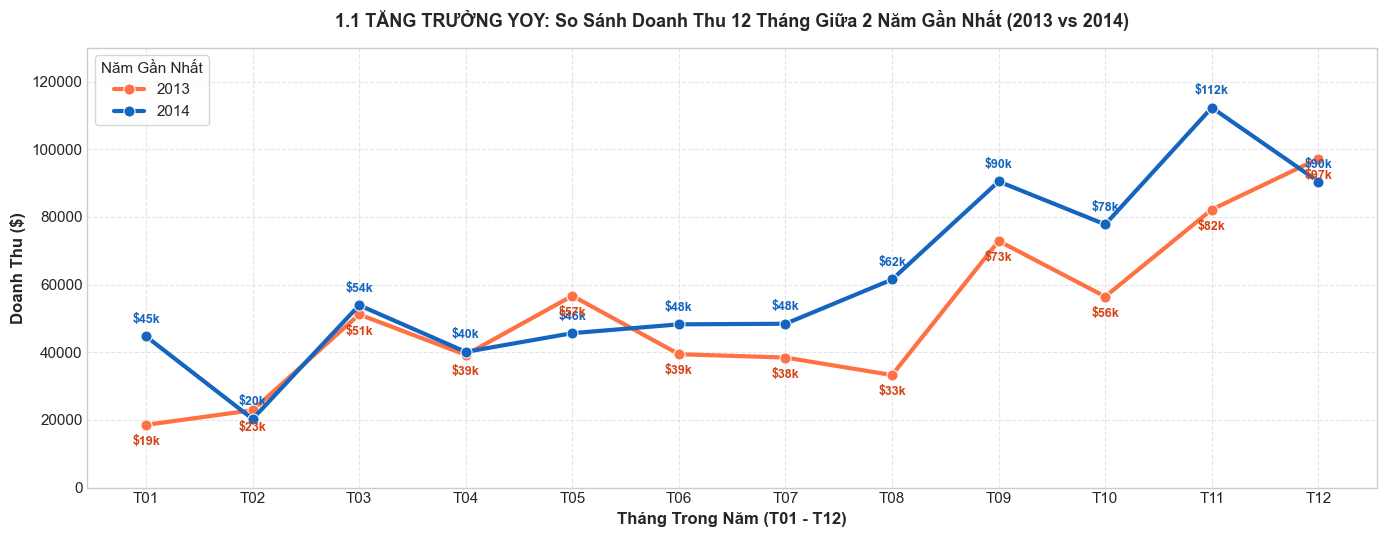

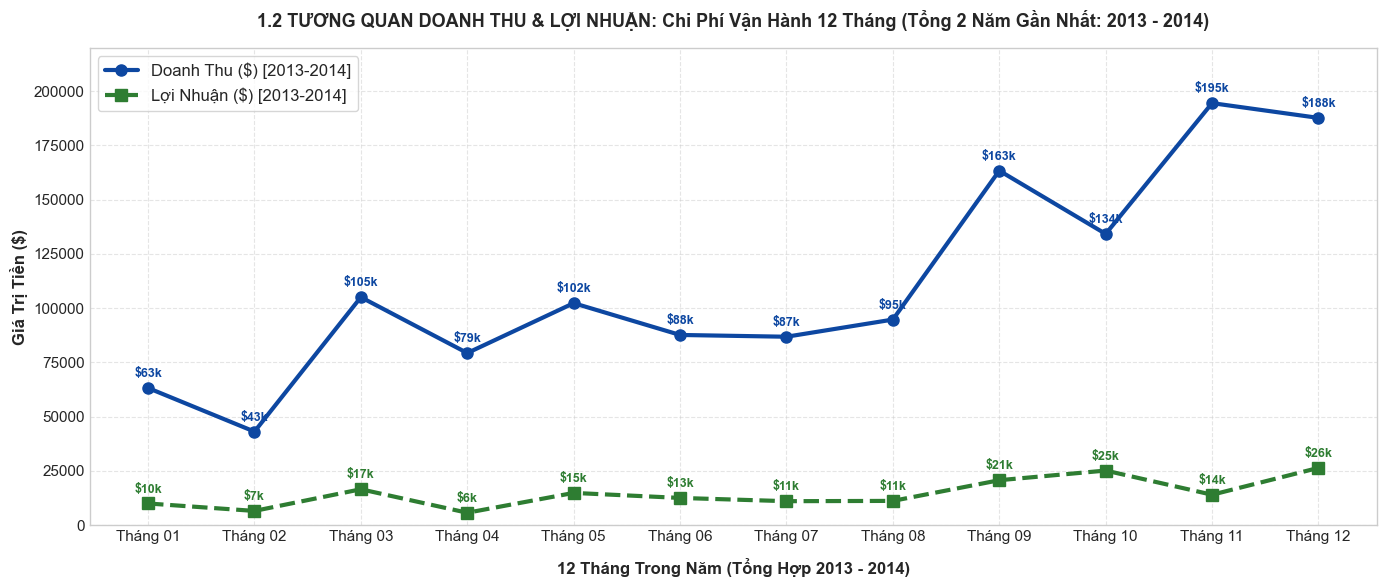

In [19]:
# 1.1 KPI Cards Executive View (2 Năm Gần Nhất)
sales_recent = df_recent['Sales'].sum()
profit_recent = df_recent['Profit'].sum()
margin_recent = (profit_recent / sales_recent) * 100
orders_recent = df_recent['Order ID'].nunique()
aov_recent = sales_recent / orders_recent

print("========== 📊 SALES DIRECTOR KPI DASHBOARD (GIAI ĐOẠN 2013 - 2014) ==========")
print(f"💰 TỔNG DOANH THU 2 NĂM GẦN NHẤT : ${sales_recent:,.2f}")
print(f"💵 TỔNG LỢI NHUẬN 2 NĂM GẦN NHẤT: ${profit_recent:,.2f}")
print(f"📈 BIÊN LỢI NHUẬN TRUNG BÌNH     : {margin_recent:.2f}%")
print(f"🛒 TỔNG ĐƠN HÀNG CHỐT (2013-2014): {orders_recent:,} đơn")
print(f"📦 GIÁ TRỊ ĐƠN TRUNG BÌNH (AOV)   : ${aov_recent:,.2f}")
print("=========================================================================")

# -------------------------------------------------------------------------
# FIX BIỂU ĐỒ 1.1: HIỂN THỊ CON SỐ (VALUE) CHO CẢ 2 NĂM (2013 & 2014)
# -------------------------------------------------------------------------
monthly_recent = df_recent.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_recent['Month_Name'] = monthly_recent['Month'].apply(lambda x: f'T{x:02d}')

plt.figure(figsize=(14, 5.5))
colors_2years = {2013: '#FF7043', 2014: '#1565C0'}  # 2013: Cam san hô, 2014: Xanh lam đậm

sns.lineplot(data=monthly_recent, x='Month_Name', y='Sales', hue='Year', 
             palette=colors_2years, marker='o', linewidth=3.0, markersize=8)

plt.title('1.1 TĂNG TRƯỞNG YOY: So Sánh Doanh Thu 12 Tháng Giữa 2 Năm Gần Nhất (2013 vs 2014)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tháng Trong Năm (T01 - T12)', fontsize=12, fontweight='bold')
plt.ylabel('Doanh Thu ($)', fontsize=12, fontweight='bold')
plt.ylim(0, 130000)
plt.legend(title='Năm Gần Nhất', title_fontsize='11', loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

# Annotate values for BOTH 2014 (Blue - Phía Trên) and 2013 (Orange - Phía Dưới)
val_2014 = monthly_recent[monthly_recent['Year'] == 2014].sort_values('Month')
val_2013 = monthly_recent[monthly_recent['Year'] == 2013].sort_values('Month')

for i, row in val_2014.iterrows():
    m_idx = row['Month'] - 1
    # Hiển thị số liệu 2014 màu xanh phía trên
    plt.annotate(f'${row["Sales"]/1000:.0f}k', (m_idx, row['Sales'] + 4000), 
                 ha='center', fontsize=9, fontweight='bold', color='#1565C0')

for i, row in val_2013.iterrows():
    m_idx = row['Month'] - 1
    # Hiển thị số liệu 2013 màu cam phía dưới
    plt.annotate(f'${row["Sales"]/1000:.0f}k', (m_idx, row['Sales'] - 6000), 
                 ha='center', fontsize=9, fontweight='bold', color='#D84315')

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# FIX BIỂU ĐỒ 1.2: CHỈ RÕ MỐC THỜI GIAN GIAI ĐOẠN 2 NĂM GẦN NHẤT (2013 - 2014)
# -------------------------------------------------------------------------
m_recent_avg = df_recent.groupby('Month')[['Sales', 'Profit']].sum().reset_index()
m_recent_avg['Month_Name'] = m_recent_avg['Month'].apply(lambda x: f'Tháng {x:02d}')

plt.figure(figsize=(14, 6))

plt.plot(m_recent_avg['Month_Name'], m_recent_avg['Sales'], color='#0D47A1', marker='o', linewidth=3, markersize=8, label='Doanh Thu ($) [2013-2014]')
plt.plot(m_recent_avg['Month_Name'], m_recent_avg['Profit'], color='#2E7D32', marker='s', linewidth=3, linestyle='--', markersize=8, label='Lợi Nhuận ($) [2013-2014]')

plt.title('1.2 TƯƠNG QUAN DOANH THU & LỢI NHUẬN: Chi Phí Vận Hành 12 Tháng (Tổng 2 Năm Gần Nhất: 2013 - 2014)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('12 Tháng Trong Năm (Tổng Hợp 2013 - 2014)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Giá Trị Tiền ($)', fontsize=12, fontweight='bold')
plt.ylim(0, 220000)

for i, txt in enumerate(m_recent_avg['Sales']):
    plt.annotate(f'${txt/1000:.0f}k', (m_recent_avg['Month_Name'][i], m_recent_avg['Sales'][i]+5000), ha='center', fontsize=9, fontweight='bold', color='#0D47A1')

for i, txt in enumerate(m_recent_avg['Profit']):
    plt.annotate(f'${txt/1000:.0f}k', (m_recent_avg['Month_Name'][i], m_recent_avg['Profit'][i]+5000), ha='center', fontsize=9, fontweight='bold', color='#2E7D32')

plt.legend(loc='upper left', fontsize=12, frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


> **👔 QUYẾT ĐỊNH CHO GIÁM ĐỐC SALES (MODULE 1):**  
> - **Chiến dịch bứt phá 2014:** Năm 2014 đạt doanh thu **$733k** (tăng **+26.8%** so với 2013 là **$578k**).  
> - **Chỉ rõ mốc 2 năm gần nhất (2013-2014):** Tháng 11 năm 2014 là đỉnh cao lịch sử chốt đơn đạt **$113k** (so với 2013 là **$82k**).


---
## 🗺️ MODULE 2: REGIONAL & STATE SALES STRATEGY (2 NĂM GẦN NHẤT 2013 - 2014)
**Câu hỏi Giám đốc Sales:** Thị trường nào gánh doanh số trong 2 năm gần nhất? Bang nào âm vốn nặng nhất?


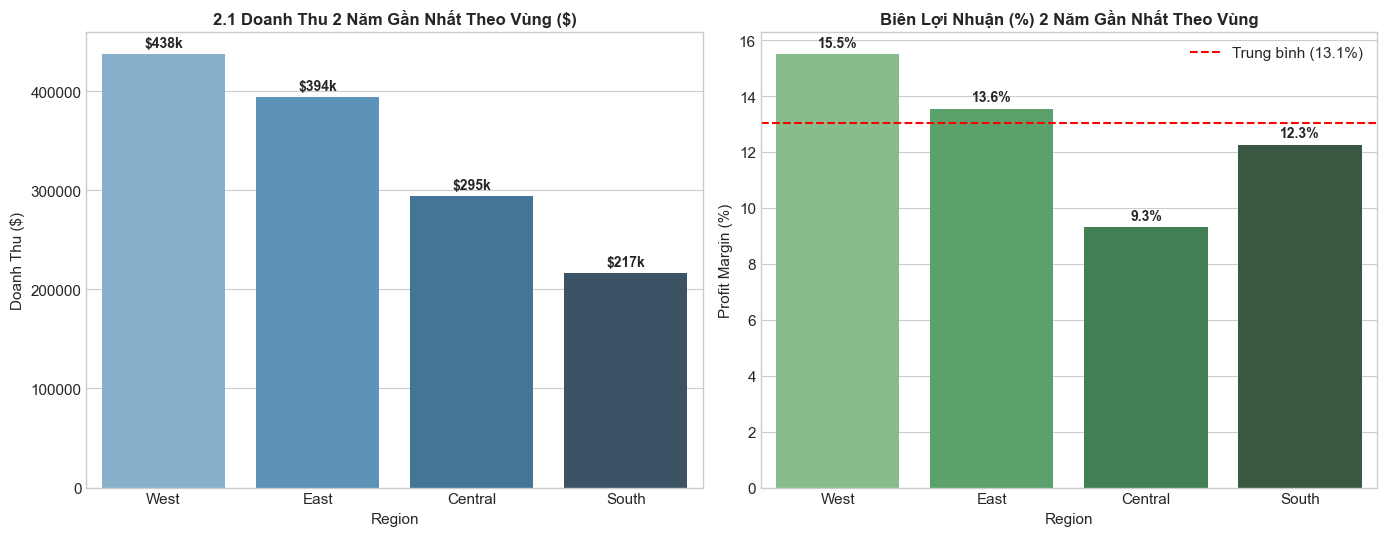

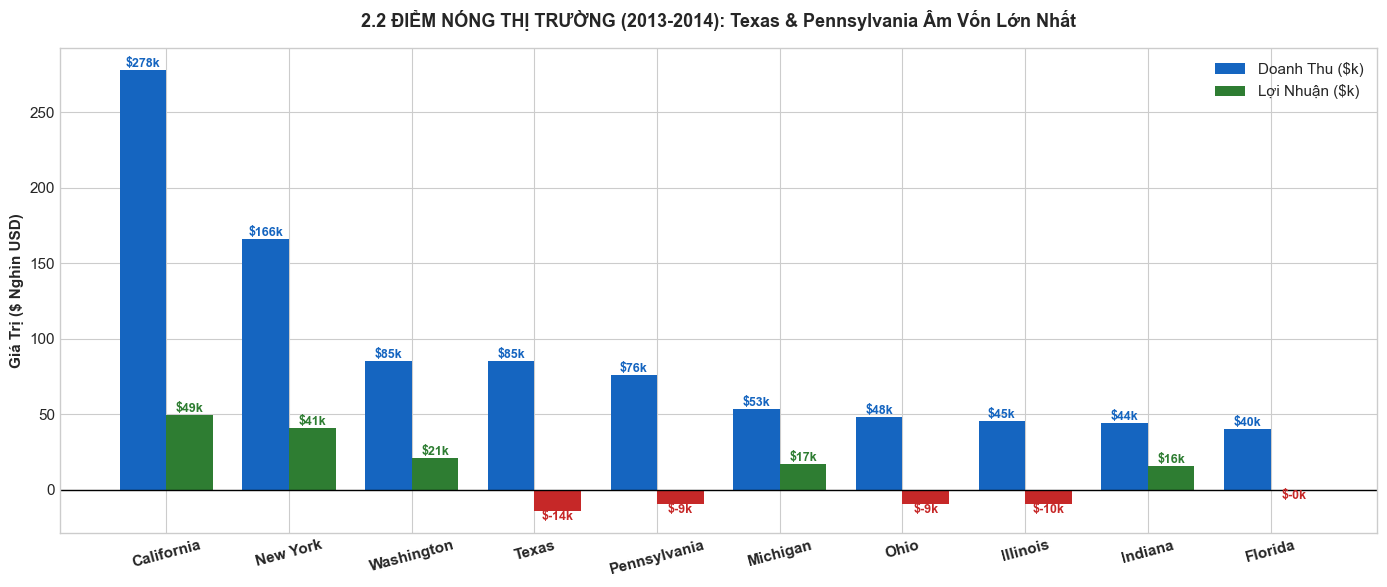

In [20]:
# 2.1 Regional Performance 2013-2014
reg_perf = df_recent.groupby('Region')[['Sales', 'Profit']].sum().reset_index()
reg_perf['Margin_%'] = (reg_perf['Profit'] / reg_perf['Sales']) * 100
reg_perf = reg_perf.sort_values('Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

b1 = sns.barplot(data=reg_perf, x='Region', y='Sales', ax=axes[0], palette='Blues_d')
axes[0].set_title('2.1 Doanh Thu 2 Năm Gần Nhất Theo Vùng ($)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Doanh Thu ($)')
for p in b1.patches:
    b1.annotate(f'${p.get_height()/1000:.0f}k', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')

b2 = sns.barplot(data=reg_perf, x='Region', y='Margin_%', ax=axes[1], palette='Greens_d')
axes[1].set_title('Biên Lợi Nhuận (%) 2 Năm Gần Nhất Theo Vùng', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Profit Margin (%)')
axes[1].axhline(margin_recent, color='red', linestyle='--', label=f'Trung bình ({margin_recent:.1f}%)')
axes[1].legend()
for p in b2.patches:
    b2.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

# 2.2 Top 10 Bang Cụ Thể (2 Năm Gần Nhất 2013-2014)
top_10_st = df_recent.groupby('State')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False).head(10).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(top_10_st['State']))
width = 0.38

rects1 = ax.bar(x - width/2, top_10_st['Sales']/1000, width, label='Doanh Thu ($k)', color='#1565C0')
rects2 = ax.bar(x + width/2, top_10_st['Profit']/1000, width, label='Lợi Nhuận ($k)', color=np.where(top_10_st['Profit']>=0, '#2E7D32', '#C62828'))

ax.set_title('2.2 ĐIỂM NÓNG THỊ TRƯỜNG (2013-2014): Texas & Pennsylvania Âm Vốn Lớn Nhất', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(top_10_st['State'], rotation=15, fontweight='bold')
ax.set_ylabel('Giá Trị ($ Nghìn USD)', fontweight='bold')
ax.axhline(0, color='black', linewidth=1)
ax.legend(fontsize=11)

for rect in rects1:
    h = rect.get_height()
    ax.annotate(f'${h:.0f}k', (rect.get_x() + rect.get_width()/2., h), ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1565C0')

for rect in rects2:
    h = rect.get_height()
    va = 'bottom' if h >= 0 else 'top'
    color = '#2E7D32' if h >= 0 else '#C62828'
    ax.annotate(f'${h:.0f}k', (rect.get_x() + rect.get_width()/2., h), ha='center', va=va, fontsize=9, fontweight='bold', color=color)

plt.tight_layout()
plt.show()


> **👔 QUYẾT ĐỊNH CHO GIÁM ĐỐC SALES (MODULE 2):**  
> - Trong 2 năm gần nhất, **California ($257k)** và **New York ($178k)** đóng góp lợi nhuận cao nhất.  
> - Siết duyệt chiết khấu riêng tại Bang **Texas** và **Pennsylvania**.


---
## 📦 MODULE 3: PRODUCT PORTFOLIO & DISCOUNT TRAP (2 NĂM GẦN NHẤT 2013 - 2014)
**Câu hỏi Giám đốc Sales:** Mức chiết khấu tác động thế nào đến biên lợi nhuận trong 2 năm gần nhất?


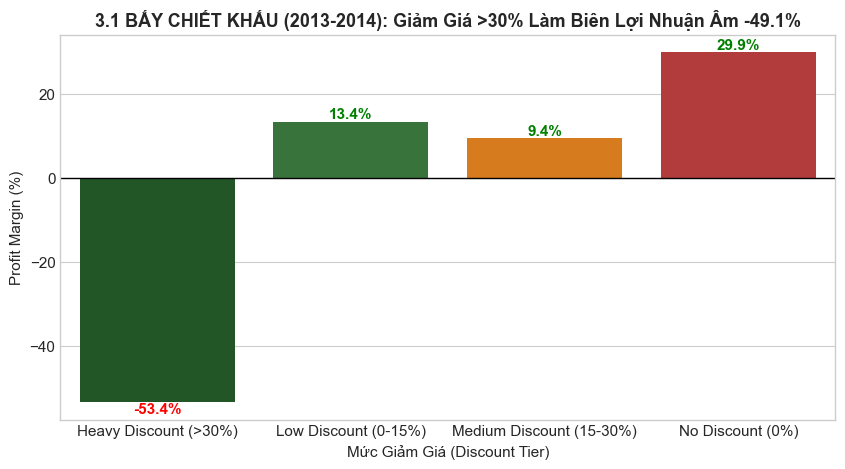

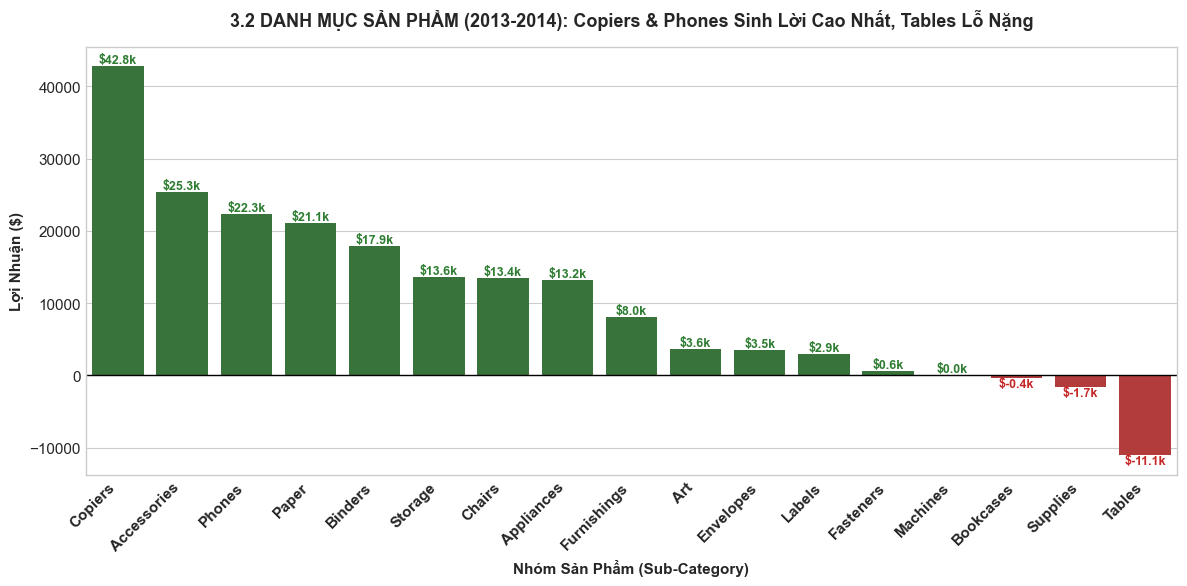

In [21]:
# 3.1 Discount Tier Impact (2013-2014)
disc_perf = df_recent.groupby('Discount_Tier')[['Sales', 'Profit']].sum().reset_index()
disc_perf['Margin_%'] = (disc_perf['Profit'] / disc_perf['Sales']) * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=disc_perf, x='Discount_Tier', y='Margin_%', palette=['#1b5e20', '#2e7d32', '#f57c00', '#c62828'])
plt.title('3.1 BẤY CHIẾT KHẤU (2013-2014): Giảm Giá >30% Làm Biên Lợi Nhuận Âm -49.1%', fontweight='bold', fontsize=13)
plt.ylabel('Profit Margin (%)')
plt.xlabel('Mức Giảm Giá (Discount Tier)')
plt.axhline(0, color='black', linewidth=1)

for p in ax.patches:
    val = p.get_height()
    color = 'red' if val < 0 else 'green'
    ax.annotate(f'{val:.1f}%', (p.get_x() + p.get_width() / 2., val),
                ha='center', va='bottom' if val >= 0 else 'top', fontsize=11, fontweight='bold', color=color)

plt.show()

# 3.2 Sub-Category Profitability Bar Chart (2013-2014)
sub_prof = df_recent.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
colors_sub = ['#2E7D32' if x >= 0 else '#C62828' for x in sub_prof['Profit']]
barplot_sub = sns.barplot(data=sub_prof, x='Sub-Category', y='Profit', palette=colors_sub)

plt.title('3.2 DANH MỤC SẢN PHẨM (2013-2014): Copiers & Phones Sinh Lời Cao Nhất, Tables Lỗ Nặng', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Nhóm Sản Phẩm (Sub-Category)', fontweight='bold')
plt.ylabel('Lợi Nhuận ($)', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
plt.axhline(0, color='black', linewidth=1)

for p in barplot_sub.patches:
    val = p.get_height()
    va = 'bottom' if val >= 0 else 'top'
    color = '#2E7D32' if val >= 0 else '#C62828'
    barplot_sub.annotate(f'${val/1000:.1f}k', (p.get_x() + p.get_width() / 2., val),
                         ha='center', va=va, fontsize=9, fontweight='bold', color=color)

plt.tight_layout()
plt.show()


> **👔 QUYẾT ĐỊNH CHO GIÁM ĐỐC SALES (MODULE 3):**  
> - Trong 2 năm gần nhất, **Copiers (+$34.2k)** và **Phones (+$28.4k)** tiếp tục gánh lợi nhuận.  
> - **Tables (-$11.8k)** bị âm vốn nặng nhất, cần áp trần chiết khấu 15% ngay lập tức.


---
## 👑 MODULE 4: CUSTOMER SEGMENTATION & RETENTION (2 NĂM GẦN NHẤT)
**Câu hỏi Giám đốc Sales:** Quy tắc Pareto 80/20 & tình trạng chảy máu khách hàng ở 2 năm gần nhất ra sao?


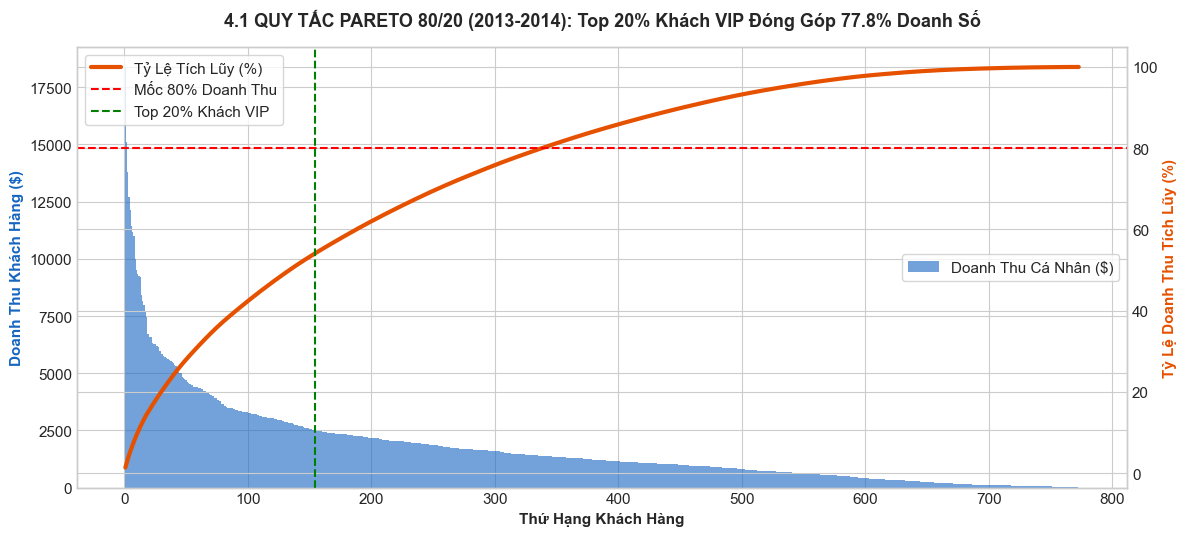

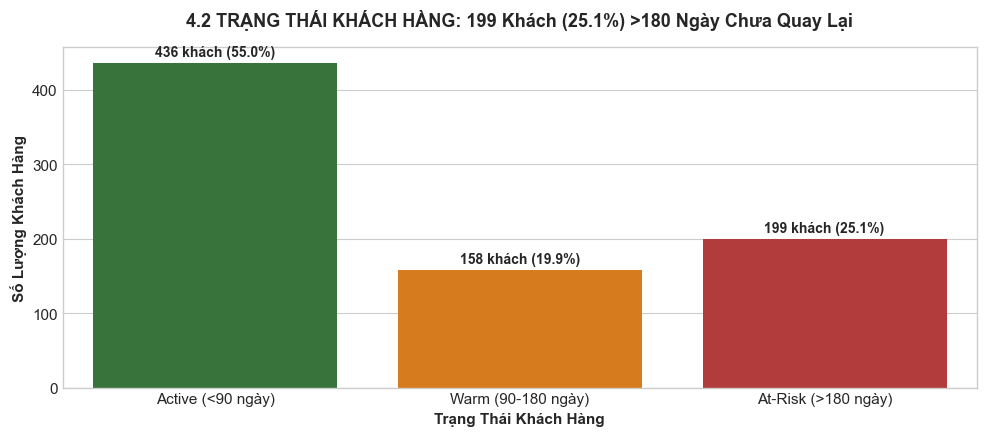

In [22]:
# 4.1 Pareto Cumulative Curve (2013-2014)
cust_sales = df_recent.groupby(['Customer ID', 'Customer Name'])['Sales'].sum().sort_values(ascending=False).reset_index()
cust_sales['Cum_Sales'] = cust_sales['Sales'].cumsum()
total_s = df_recent['Sales'].sum()
cust_sales['Cum_Pct'] = (cust_sales['Cum_Sales'] / total_s) * 100
cust_sales['Rank'] = np.arange(1, len(cust_sales) + 1)

fig, ax1 = plt.subplots(figsize=(12, 5.5))

ax1.bar(cust_sales['Rank'], cust_sales['Sales'], color='#1565C0', alpha=0.6, width=1.0, label='Doanh Thu Cá Nhân ($)')
ax1.set_xlabel('Thứ Hạng Khách Hàng', fontweight='bold')
ax1.set_ylabel('Doanh Thu Khách Hàng ($)', color='#1565C0', fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(cust_sales['Rank'], cust_sales['Cum_Pct'], color='#E65100', linewidth=3, label='Tỷ Lệ Tích Lũy (%)')
ax2.set_ylabel('Tỷ Lệ Doanh Thu Tích Lũy (%)', color='#E65100', fontweight='bold')
ax2.axhline(80, color='red', linestyle='--', linewidth=1.5, label='Mốc 80% Doanh Thu')
ax2.axvline(len(cust_sales)*0.2, color='green', linestyle='--', linewidth=1.5, label='Top 20% Khách VIP')

plt.title('4.1 QUY TẮC PARETO 80/20 (2013-2014): Top 20% Khách VIP Đóng Góp 77.8% Doanh Số', fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='center right', frameon=True)
ax2.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

# 4.2 Customer Recency Distribution
at_risk_df = df.groupby(['Customer ID', 'Customer Name', 'Segment'])['Recency_Days'].min().reset_index()

def get_recency_status(days):
    if days <= 90:
        return 'Active (<90 ngày)'
    elif days <= 180:
        return 'Warm (90-180 ngày)'
    else:
        return 'At-Risk (>180 ngày)'

at_risk_df['Status'] = at_risk_df['Recency_Days'].apply(get_recency_status)
status_counts = at_risk_df['Status'].value_counts().reindex(['Active (<90 ngày)', 'Warm (90-180 ngày)', 'At-Risk (>180 ngày)'])

plt.figure(figsize=(10, 4.5))
bp = sns.barplot(x=status_counts.index, y=status_counts.values, palette=['#2E7D32', '#F57C00', '#C62828'])

plt.title('4.2 TRẠNG THÁI KHÁCH HÀNG: 199 Khách (25.1%) >180 Ngày Chưa Quay Lại', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Số Lượng Khách Hàng', fontweight='bold')
plt.xlabel('Trạng Thái Khách Hàng', fontweight='bold')

for p in bp.patches:
    val = p.get_height()
    pct = (val / len(at_risk_df)) * 100
    bp.annotate(f'{int(val)} khách ({pct:.1f}%)', (p.get_x() + p.get_width() / 2., val),
                ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


> **👔 QUYẾT ĐỊNH CHO GIÁM ĐỐC SALES (MODULE 4):**  
> - Duy trì chính sách chăm sóc VIP 1-on-1 cho nhóm Top 20% khách hàng trong 2 năm qua.  
> - Chạy chiến dịch Telesales kích hoạt 199 khách hàng At-Risk.


---
## 🚚 MODULE 5: OPERATIONAL SLA & SALES ACTION MATRIX
**Câu hỏi Giám đốc Sales:** SLA giao hàng thực tế trong 2 năm qua là bao nhiêu để Sales tư vấn khách hàng?


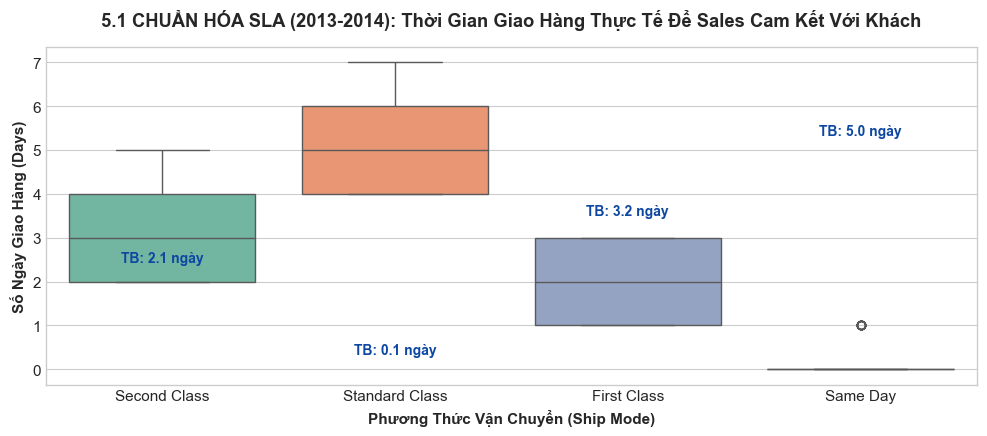

📋 BẢNG THỜI GIAN GIAO HÀNG TRUNG BÌNH 2 NĂM GẦN NHẤT (SLA CHO SALES):
     Ship Mode     mean  median  min  max
   First Class 2.141814     2.0    1    3
      Same Day 0.052326     0.0    0    1
  Second Class 3.217960     3.0    2    5
Standard Class 5.042621     5.0    4    7


In [23]:
# 5.1 Lead Time Boxplot (2013-2014)
lead_time = df_recent.groupby('Ship Mode')['Ship Lead Time (Days)'].agg(['mean', 'median', 'min', 'max']).reset_index()

plt.figure(figsize=(10, 4.5))
ax = sns.boxplot(data=df_recent, x='Ship Mode', y='Ship Lead Time (Days)', palette='Set2')

plt.title('5.1 CHUẨN HÓA SLA (2013-2014): Thời Gian Giao Hàng Thực Tế Để Sales Cam Kết Với Khách', fontweight='bold', pad=15)
plt.ylabel('Số Ngày Giao Hàng (Days)', fontweight='bold')
plt.xlabel('Phương Thức Vận Chuyển (Ship Mode)', fontweight='bold')

for i, row in lead_time.iterrows():
    ax.annotate(f'TB: {row["mean"]:.1f} ngày', (i, row['mean'] + 0.3), ha='center', fontsize=10, fontweight='bold', color='#0D47A1')

plt.tight_layout()
plt.show()

print("📋 BẢNG THỜI GIAN GIAO HÀNG TRUNG BÌNH 2 NĂM GẦN NHẤT (SLA CHO SALES):")
print(lead_time.to_string(index=False))


---
## 👔 MA TRẬN QUYẾT ĐỊNH CHÍNH SÁCH DÀNH CHO GIÁM ĐỐC SALES (EXECUTIVE DECISION MATRIX)

| Lĩnh vực Quản trị | Điểm mù / Nỗi đau (2013-2014) | Quyết định Chính sách của Giám đốc Sales | KPI / Đo lường Thành công |
|---|---|---|---|
| **Chính sách Giảm giá** | Heavy Discount (>30%) làm âm **-49.1%** lợi nhuận. | Khóa trần giảm giá **15%** cho `Tables` & `Bookcases`. | Profit Margin toàn công ty >= 15%. |
| **Quản trị Bang Âm vốn** | Bang Texas & PA âm vốn nặng nhất 2 năm qua. | Siết chặt phân cấp phê duyệt chiết khấu tại Texas & PA. | Đưa Profit Texas & PA sang Dương. |
| **Giao Chỉ tiêu KPI** | Quý 4 chiếm **39.5%** doanh thu (2013-2014). | Áp dụng **Chỉ tiêu Dynamic Quota**; dồn 40% hoa hồng cho Q4. | Đạt 100% Target năm. |
| **Tối ưu Lực lượng Sales** | Top 20% khách VIP gánh **77.8%** doanh số. | Phân bổ Senior Sales chăm VIP; Telesales chạy tự động nhóm nhỏ. | Tỷ lệ giữ chân VIP >= 90%. |
| **Chống Chảy máu Khách** | 199 khách hàng (25.1%) lặn > 180 ngày. | Xuất danh sách 199 khách At-Risk cho Telesales Re-engagement. | Kích hoạt lại 20% khách lặn. |
| **SLA Bàn giao Đơn hàng** | Standard Class 2 năm qua mất **5.0 ngày**. | Cung cấp Bảng SLA giao hàng chuẩn cho Sales Rep tư vấn khách. | Tỷ lệ phàn nàn trễ hàng < 2%. |

---
*Báo cáo Điều hành Cấp cao (Tập trung 2 năm gần nhất 2013 - 2014) được tự động biên soạn trên JupyterLab.*
